# Stochastic control backtest — results

Walk-forward out-of-sample results for the dynamic programming controller, scored under
`docs/experiments/scoring_rule.md`: cash revenue over the scored week plus `q` times the energy
still stored at its end.

This notebook reads `results/historical_*.csv` rather than re-running the backtest, so every
figure here matches the README. To regenerate those results from scratch:

    python scripts/capture_dp_reference.py     # frozen reference from the git tag
    python scripts/check_dp_reproduction.py    # re-solves, verifies, writes results/

In [1]:
import sys
from pathlib import Path

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.windows import load_windows

pd.set_option("display.width", 120)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

MARKETS = [("CISO", "CISO"), ("NYISO", "NYIS")]

def load(code_):
    """Scored weekly results, one row per week per method (see docs/experiments/scoring_rule.md)."""
    t = pd.read_csv(ROOT / "results" / f"historical_{code_}.csv", float_precision="round_trip")
    wide = t.pivot(index="week_idx", columns="method", values="score")
    info = t[t.method == "dp"].sort_values("week_idx").set_index("week_idx")
    return t, wide, info

def stats(s, pf):
    return {"mean weekly score": s.mean(), "value capture": s.sum() / pf.sum(),
            "Sharpe": s.mean() / s.std(ddof=0), "win rate": (s > 0).mean(), "worst week": s.min()}

## Headline results

In [2]:
rows = {}
for name, c in MARKETS:
    t, wide, info = load(c)
    rows[name] = {"weeks": len(wide), **stats(wide["dp"], info.pf_score),
                  "perfect foresight": info.pf_score.mean()}
summary = pd.DataFrame(rows).T
summary.style.format({"mean weekly score": "${:,.0f}", "value capture": "{:.1%}", "Sharpe": "{:.2f}",
                      "win rate": "{:.0%}", "worst week": "${:,.0f}", "perfect foresight": "${:,.0f}"})

,weeks,mean weekly score,value capture,Sharpe,win rate,worst week,perfect foresight
CISO,114.000000,"$14,559",79.5%,1.47,99%,"$-2,195","$18,314"
NYISO,333.000000,"$10,918",65.5%,1.32,99%,$0,"$16,674"


## The scoring correction

Earlier versions of this project scored weeks on cash alone. That let the controller beat its own
perfect-foresight ceiling, because perfect foresight rationally ends a week holding inventory that
cash-only scoring throws away. Counting that inventory at `q` removes the anomaly.

In [3]:
for name, c in MARKETS:
    t, wide, info = load(c)
    dp, pf = t[t.method == "dp"].set_index("week_idx"), t[t.method == "pf"].set_index("week_idx")
    cash_beats = (dp.revenue > pf.revenue).sum()
    cash_ratio = dp.revenue.sum() / pf.revenue.sum()
    cash_mean_of_ratios = np.mean([r / p if p > 0 else 0 for r, p in zip(dp.revenue, pf.revenue)])
    print(f"{name}: DP beat perfect foresight in {cash_beats} of {len(dp)} weeks under cash-only scoring, "
          f"0 under the scoring rule")
    print(f"   value capture  cash-only {cash_ratio:.1%} (mean of ratios {cash_mean_of_ratios:.1%})"
          f"   ->  scored {dp.score.sum() / dp.pf_score.sum():.1%}")
    print(f"   DP leaves {dp.soc_end.mean():.1f} MWh stored at week end on average "
          f"(${(dp.soc_end * dp.q).mean():,.0f})\n")

CISO: DP beat perfect foresight in 11 of 114 weeks under cash-only scoring, 0 under the scoring rule
   value capture  cash-only 82.0% (mean of ratios 74.5%)   ->  scored 79.5%
   DP leaves 20.3 MWh stored at week end on average ($842)

NYISO: DP beat perfect foresight in 93 of 333 weeks under cash-only scoring, 0 under the scoring rule
   value capture  cash-only 71.8% (mean of ratios 86.4%)   ->  scored 65.5%
   DP leaves 15.3 MWh stored at week end on average ($688)



## Weekly scores

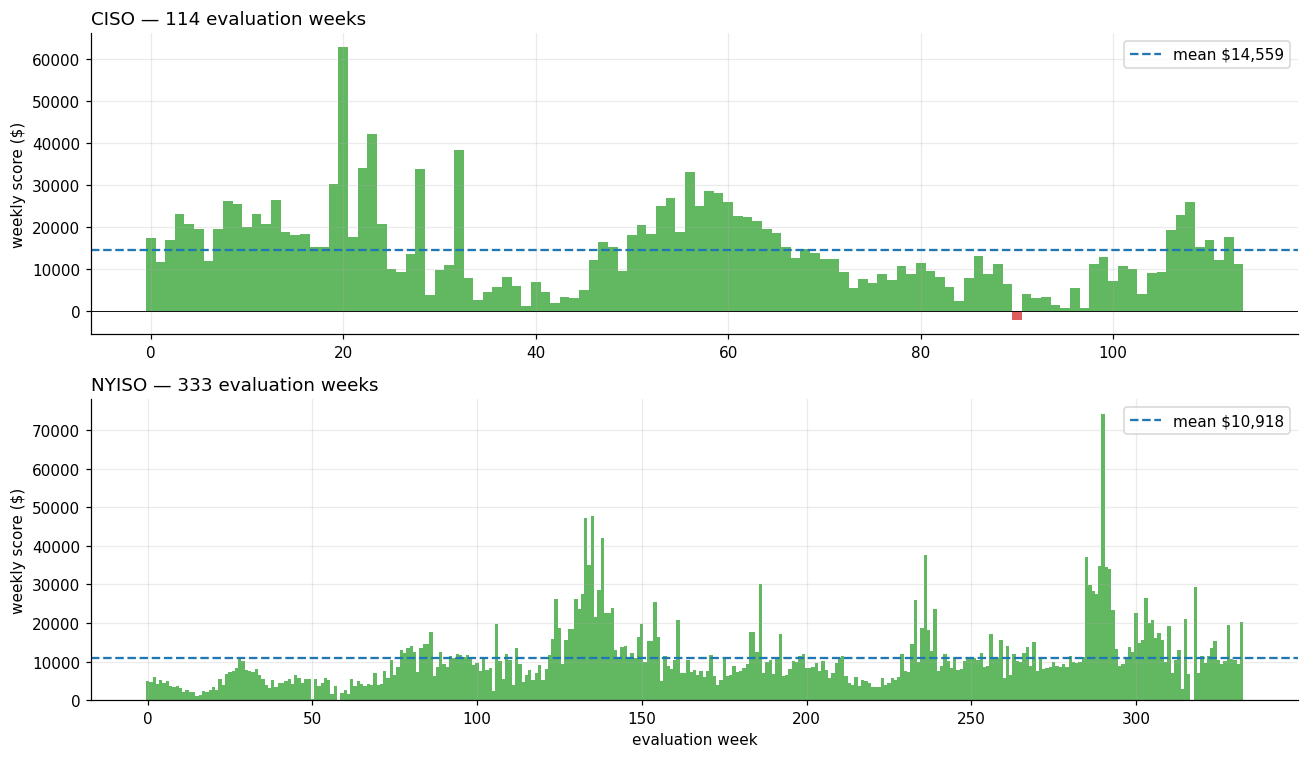

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
for ax, (name, c) in zip(axes, MARKETS):
    _, wide, _ = load(c)
    s = wide["dp"]
    ax.bar(range(len(s)), s, color=["#2ca02c" if v > 0 else "#d62728" for v in s], alpha=0.75, width=1.0)
    ax.axhline(0, color="black", lw=0.6)
    ax.axhline(s.mean(), color="#1f77b4", ls="--", label=f"mean ${s.mean():,.0f}")
    ax.set_ylabel("weekly score ($)"); ax.set_title(f"{name} — {len(s)} evaluation weeks", loc="left")
    ax.legend()
axes[1].set_xlabel("evaluation week")
plt.tight_layout(); plt.show()

## Cumulative score and drawdown

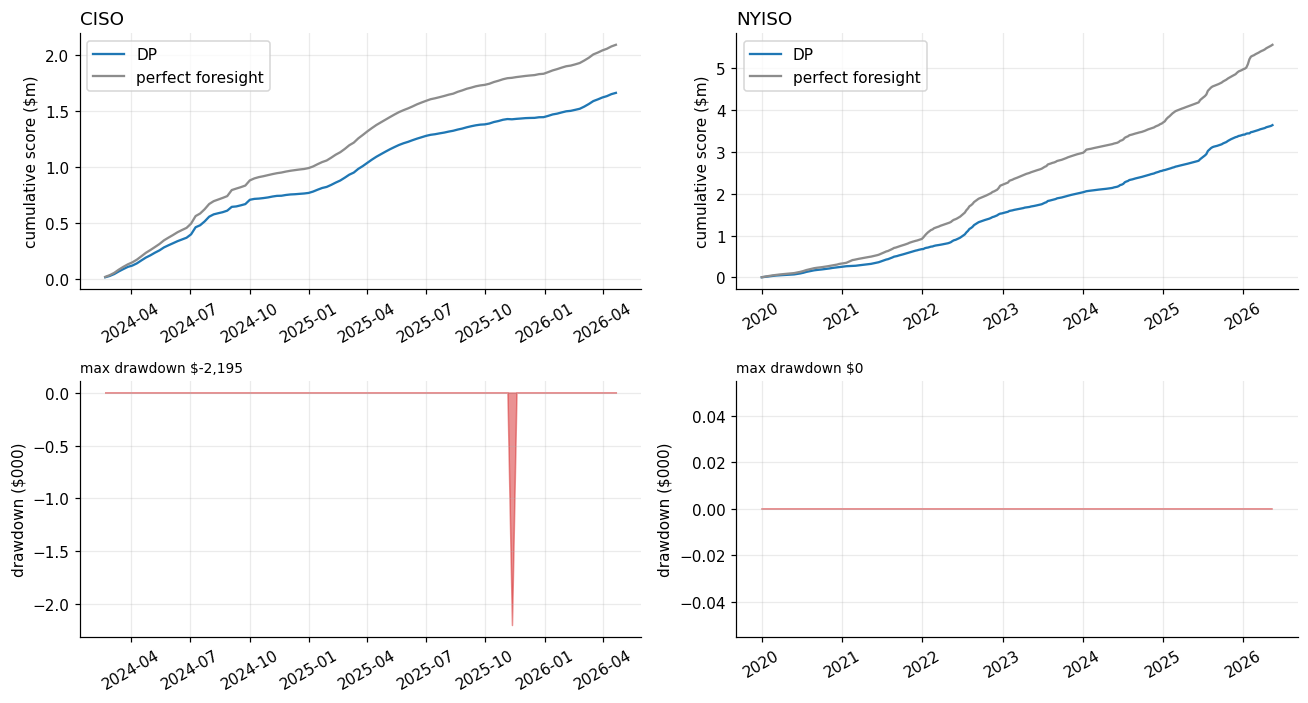

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6.5))
for col, (name, c) in enumerate(MARKETS):
    _, wide, info = load(c)
    dates = pd.to_datetime(info.eval_start_ts.values)
    cum = wide["dp"].cumsum().values
    axes[0, col].plot(dates, cum / 1e6, color="#1f77b4", label="DP")
    axes[0, col].plot(dates, info.pf_score.cumsum().values / 1e6, color="#8c8c8c", label="perfect foresight")
    axes[0, col].set_ylabel("cumulative score ($m)"); axes[0, col].set_title(name, loc="left")
    axes[0, col].legend()
    dd = cum - np.maximum.accumulate(cum)
    axes[1, col].fill_between(dates, dd / 1000, color="#d62728", alpha=0.5)
    axes[1, col].set_ylabel("drawdown ($000)")
    axes[1, col].set_title(f"max drawdown ${dd.min():,.0f}", loc="left", fontsize=9)
    for ax in axes[:, col]:
        ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## Trimmed and untrimmed Sharpe

The scoring rule reports untrimmed weekly Sharpe. Earlier versions trimmed five weeks from each
tail, which removes 9% of CISO weeks but only 3% of NYISO's, so the two markets were not comparable.
Both are shown here for continuity.

In [6]:
for name, c in MARKETS:
    _, wide, _ = load(c)
    s = np.sort(wide["dp"].values)
    trimmed = s[5:-5]
    print(f"{name}: untrimmed {s.mean() / s.std():.2f}  |  trimmed [5:-5] {trimmed.mean() / trimmed.std():.2f}"
          f"  ({10 / len(s):.0%} of weeks removed)")

CISO: untrimmed 1.47  |  trimmed [5:-5] 1.87  (9% of weeks removed)
NYISO: untrimmed 1.32  |  trimmed [5:-5] 1.59  (3% of weeks removed)


## Realized volatility against revenue

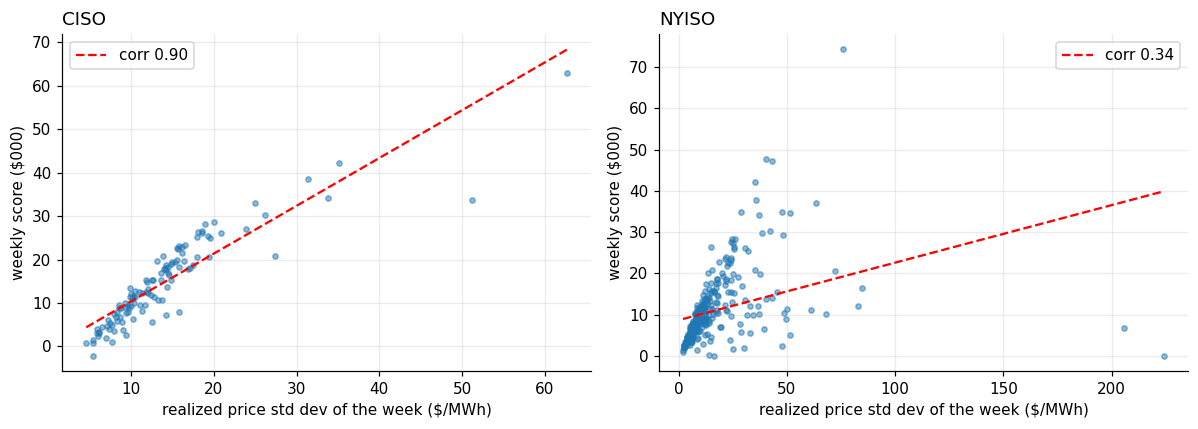

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, c) in zip(axes, MARKETS):
    _, wide, info = load(c)
    W = load_windows(ROOT / "results" / f"windows_{c}.npz")
    vol = np.array([w["prices"][:168].std() for w in W])
    s = wide["dp"].values
    ax.scatter(vol, s / 1000, s=12, alpha=0.5)
    z = np.polyfit(vol, s / 1000, 1)
    xs = np.linspace(vol.min(), vol.max(), 50)
    ax.plot(xs, np.polyval(z, xs), "r--", label=f"corr {np.corrcoef(vol, s)[0, 1]:.2f}")
    ax.set_xlabel("realized price std dev of the week ($/MWh)"); ax.set_ylabel("weekly score ($000)")
    ax.set_title(name, loc="left"); ax.legend()
plt.tight_layout(); plt.show()

## Calibration stability

The OU parameters are re-estimated every week. Half-life varies by more than an order of magnitude,
which is the symptom of fitting one AR(1) to a residual that actually has a fast component
(~11h in CISO, ~35h in NYISO) and a slow one (~240h). NYISO also hits the θ ≥ 0.01 clamp in 22% of
windows, visible as the flat ceiling.

CISO: half-life p5 2.7h, median 10.9h, p95 52.6h | at clamp: 1%
NYISO: half-life p5 12.3h, median 32.8h, p95 69.3h | at clamp: 22%


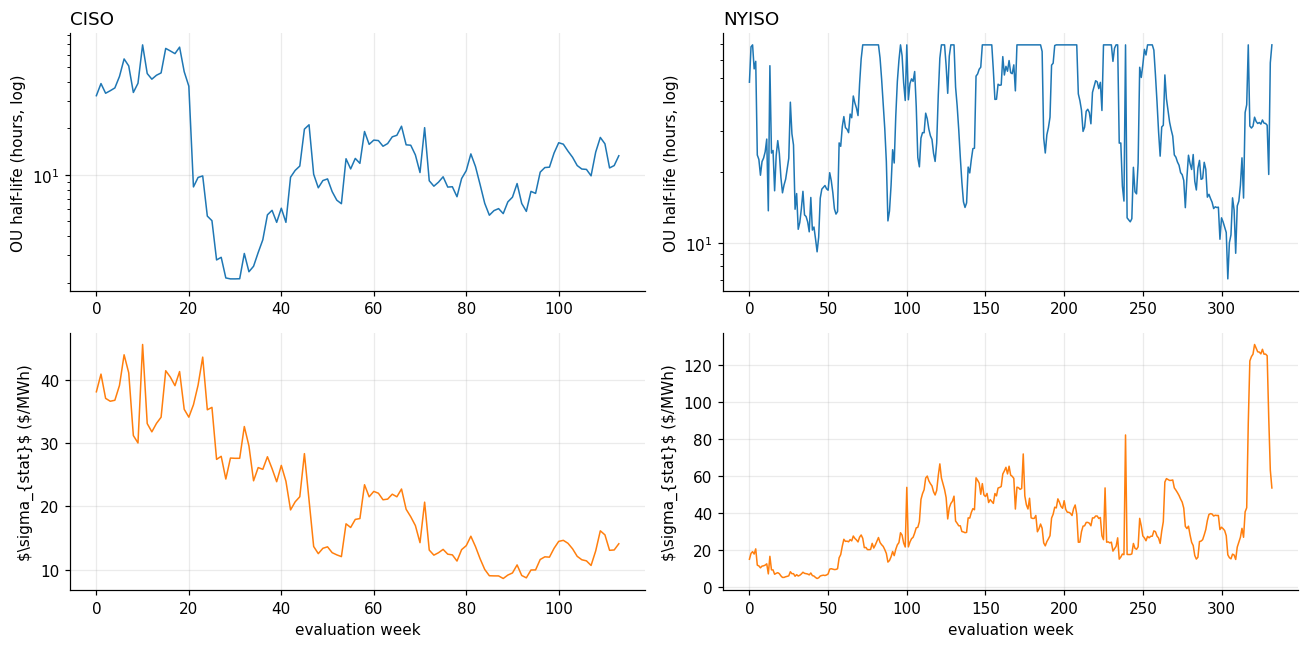

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for col, (name, c) in enumerate(MARKETS):
    W = load_windows(ROOT / "results" / f"windows_{c}.npz")
    hl = np.array([np.log(2) / w["theta"] for w in W])
    ss = np.array([w["sigma"] / np.sqrt(2 * w["theta"]) for w in W])
    axes[0, col].plot(hl, lw=1); axes[0, col].set_yscale("log")
    axes[0, col].set_ylabel("OU half-life (hours, log)"); axes[0, col].set_title(name, loc="left")
    axes[1, col].plot(ss, lw=1, color="#ff7f0e"); axes[1, col].set_ylabel(r"$\sigma_{stat}$ ($/MWh)")
    axes[1, col].set_xlabel("evaluation week")
    print(f"{name}: half-life p5 {np.percentile(hl, 5):.1f}h, median {np.median(hl):.1f}h, "
          f"p95 {np.percentile(hl, 95):.1f}h | at clamp: {np.mean(hl >= 69.3) :.0%}")
plt.tight_layout(); plt.show()

## Variance decomposition and the declining opportunity

Total price variation, the residual the OU model sees, and the average daily spread that actually
drives arbitrage revenue. The CISO trend is the market-saturation story: daily spreads compress
over the sample.

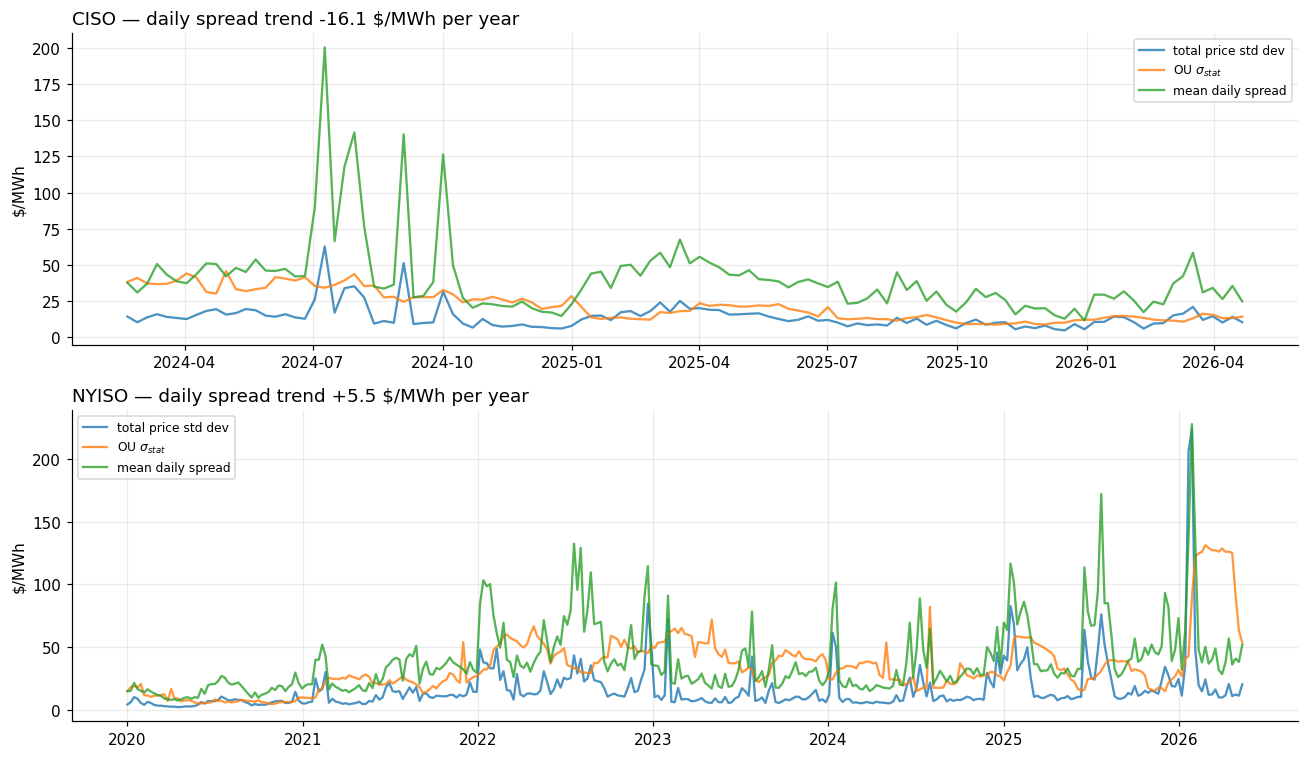

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
for ax, (name, c) in zip(axes, MARKETS):
    _, wide, info = load(c)
    W = load_windows(ROOT / "results" / f"windows_{c}.npz")
    dates = pd.to_datetime(info.eval_start_ts.values)
    total = np.array([w["prices"][:168].std() for w in W])
    spread = np.array([np.mean([w["prices"][d * 24:(d + 1) * 24].ptp() for d in range(7)]) for w in W])
    ss = np.array([w["sigma"] / np.sqrt(2 * w["theta"]) for w in W])
    ax.plot(dates, total, label="total price std dev", alpha=0.8)
    ax.plot(dates, ss, label=r"OU $\sigma_{stat}$", alpha=0.8)
    ax.plot(dates, spread, label="mean daily spread", alpha=0.8)
    trend = np.polyfit(np.arange(len(spread)), spread, 1)[0] * 52
    ax.set_title(f"{name} — daily spread trend {trend:+,.1f} $/MWh per year", loc="left")
    ax.set_ylabel("$/MWh"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

The reinforcement learning comparison, the baselines and the paired statistics are in
`04_rl.ipynb`. Registered decisions are in `docs/experiments/`.